# Testing Hypotheses to Increase Revenue in an Online Store (A/B Test)

The analysis is conducted for large online store. Together with the marketing department, we've prepared a list of hypotheses for increasing revenue.
We need to prioritize the hypotheses, run an A/B test, and analyze the results.

## Contents:
* [Step 1. Hypothesis Prioritization](#1-bullet)
* 1.1. [The ICE Framework for Hypothesis Prioritization](#1-1-bullet)
* 1.2. [The RICE Framework for Hypothesis Prioritization](#1-2-bullet)
* 1.3. [Differences in Results When Using RICE and ICE](#1-3-bullet)
* [Step 2. A/B Test Analysis](#2-bullet)
* 2.1. [Cumulative Revenue Graph by Group](#2-1-bullet)
* 2.2. [Cumulative Average Order Value Graph by Group](#2-2-bullet)
* 2.3. [Graph of the Relative Change in the Cumulative Average Order Value of Group B Versus Group A](#2-3-bullet)
* 2.4. [Graph of the Cumulative Conversion Rate by Group](#2-4-bullet)
* 2.5. [Graph of the Relative Change in the Cumulative Conversion Rate of Group B Versus Group A](#2-5-bullet)
* 2.6. [Graph of the Number of Orders by User](#2-6-bullet)
* 2.7. [95th and 99th Percentiles of the Number of Orders per User. The Cutoff for Identifying Anomalous Users](#2-7-bullet)
* 2.8. [Graph of the Order Value](#2-8-bullet)
* 2.9. [95th and 99th Percentiles of the Order Value. Boundary for Detecting Outlier Orders](#2-9-bullet)
* 2.10.[Statistical Significance of Differences in Conversion Rates Between Groups Based on Raw Data](#2-10-bullet)
* 2.11.[Statistical Significance of Differences in Average Order Value Between Groups Based on Raw Data](#2-11-bullet)
* 2.12.[Statistical Significance of Differences in Conversion Rates Between Groups Based on Cleaned Data](#2-12-bullet)
* 2.13.[Statistical Significance of Differences in Average Order Value Between Groups Based on Cleaned Data](#2-13-bullet)
* [Step 3. Decision Based on A/B Test Results](#3-bullet)

## Step 1. Hypothesis Prioritization<a class="anchor" id="1-bullet"></a>

The file contains 9 hypotheses for increasing online store revenue with the specified parameters Reach, Impact, Confidence, and Effort.

In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as stats

In [2]:
df_hypothesis = pd.read_csv('https://code.s3.yandex.net/datasets/hypothesis.csv')
df_hypothesis

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3
6,Показать на главной странице баннеры с актуаль...,5,3,8,3
7,Добавить форму подписки на все основные страни...,10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5


**Hypothesis Table**

* Hypothesis — a Brief Description of the Hypothesis;
* Reach — User Reach on a 10-point Scale;
* Impact — the Impact on Users on a 10-point Scale;
* Confidence — Confidence in the Hypothesis on a 10-point Scale;
* Efforts — the Resource Costs of Testing the Hypothesis on a 10-point Scale. The Higher the Efforts Value, the More Expensive the Hypothesis Testing.

In [3]:
df_hypothesis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [4]:
df_hypothesis.duplicated().sum()

0

    The table contains no missing values, no duplicates, and no data types that need to be changed. Column names must be converted to lowercase.

In [5]:
df_hypothesis.columns = df_hypothesis.columns.str.lower()
df_hypothesis.columns

Index(['hypothesis', 'reach', 'impact', 'confidence', 'efforts'], dtype='object')

In [6]:
df_hypothesis['hypothesis'].unique()

array(['Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей',
       'Запустить собственную службу доставки, что сократит срок доставки заказов',
       'Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа',
       'Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар',
       'Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей',
       'Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов',
       'Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию',
       'Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок',
       'Запустить акцию, дающую скидку на товар в день рождения'],
      dtype=object)

The file contains 9 hypotheses for increasing online store revenue with the specified parameters Reach, Impact, Confidence, and Effort.

### 1.1. The ICE Framework for Hypothesis Prioritization<a class="anchor" id="1-1-bullet"></a>

In [7]:
pd.set_option('max_colwidth', 120)

In [8]:
df_hypothesis['ICE'] = df_hypothesis['impact']*df_hypothesis['confidence']/df_hypothesis['efforts']
               
df_hypothesis[['hypothesis','ICE']].sort_values(by='ICE', ascending=False).round(1) 

,hypothesis,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.2
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.2
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.1
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.0


    The ICE framework consists of three components:
    Impact — how much the change will impact users, their experience, and satisfaction
    with the product;
    Confidence — how confident are you that this change will impact users in this way;
    Efforts — how much it costs to test this hypothesis.

    The ICE framework identified the top three hypotheses:
    1. Launch a promotion offering a birthday discount on a product - 16.2
    2. Add two new traffic acquisition channels, which will attract 30% more
    users - 13.3
    3. Add a subscription form to all key pages to build a customer base for
    email newsletters - 11.2

### 1.2. The RICE Framework for Hypothesis Prioritization<a class="anchor" id="1-2-bullet"></a>


In [9]:
df_hypothesis['RICE'] = df_hypothesis['reach']*df_hypothesis['impact']*df_hypothesis['confidence']/df_hypothesis['efforts']
df_hypothesis[['hypothesis','RICE']].sort_values(by='RICE', ascending=False)

,hypothesis,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3.0


    The RICE framework consists of four components:
    Reach — how many users will the change you want to make affect;
    Impact — how much the change will impact users, their experience, and satisfaction
    with the product;
    Confidence — how confident are you that this change will impact users in this way;
    Efforts — how much it will cost to test this hypothesis.

    The RICE framework has identified the top three hypotheses:
    1. Add a subscription form to all main pages to build a customer base for
    email newsletters - 112.0
    2. Add product recommendation blocks to the online store website to increase conversion
    and average order value - 56.0
    3. Add two new traffic acquisition channels to attract 30%
    more users - 40

### 1.3. Differences in Results When Using RICE and ICE<a class="anchor" id="1-3-bullet"></a>

    The RICE framework takes into account the reach metric—how many users a change will affect.

    Comparing both results:
    1. When taking reach into account, the hypothesis "Launch a promotion offering a discount
    on a product on a birthday" dropped from the top 3 hypotheses, as the changes affect a small audience.
    2. When taking reach into account, the hypothesis "Add a subscription form to all main pages
    to build a customer base for email campaigns" moved from 3rd place to first, as
    the changes will affect the maximum number of users.

## Step 2. A/B Test Analysis <a class="anchor" id="2-bullet"></a>

### Data preprocessing 

In [10]:
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders.csv')

In [11]:
df_orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


***Orders Table***

* transactionId — Order ID;
* visitorId — ID of the User;
* date — Date the Order Was Placed;
* revenue — Order Revenue;
* group — A/B Test Group the Order Was Placed In.

In [12]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [13]:
df_orders['transactionId'].duplicated().sum()

0

In [14]:
df_orders.duplicated().sum()

0

    There are no missing values ​​or duplicates in the table.
    In the ['date'] column, the data type must be changed to datetime.

In [15]:
df_orders['date'] = pd.to_datetime(df_orders['date'])

In [16]:
df_orders.dtypes

transactionId             int64
visitorId                 int64
date             datetime64[ns]
revenue                   int64
group                    object
dtype: object

In [17]:
df_orders['group'].unique()

array(['B', 'A'], dtype=object)

    The orders table contains two unique A/B test groups.

In [18]:
df_visitors = pd.read_csv('https://code.s3.yandex.net/datasets/visitors.csv')
df_visitors.head()

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


***Visitors Table***

* date — Date;
* group — A/B Test Group;
* visitors — Number of Users on the Specified Date in the Specified A/B Test Group

In [19]:
df_visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [20]:
df_visitors.duplicated().sum()

0

    There are no missing values ​​or duplicates in the table.
    In the ['date'] column, the data type must be changed to datetime.

In [21]:
df_visitors['date'] = pd.to_datetime(df_visitors['date'])

In [22]:
df_visitors.dtypes

date        datetime64[ns]
group               object
visitors             int64
dtype: object

In [23]:
df_visitors['group'].unique()

array(['A', 'B'], dtype=object)

    The visitors table has two unique A/B test groups.

### 2.1. Cumulative Revenue Graph by Group <a class="anchor" id="2-1-bullet"></a>

In [24]:
# We create an array of unique pairs of date values and test groups.
datesGroups = df_orders[['date','group']].drop_duplicates()

In [25]:
# We obtain aggregated cumulative data on orders by day
ordersAggregated = datesGroups.apply(lambda x: df_orders[np.logical_and(df_orders['date'] <= x['date'], df_orders['group'] == x['group'])].agg({'date' : 'max', 'group' : 'max', 'transactionId' : pd.Series.nunique, 'visitorId' : pd.Series.nunique, 'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])

In [26]:
ordersAggregated.columns = ['date', 'group', 'orders', 'buyers', 'revenue']

In [27]:
ordersAggregated.head()

,date,group,orders,buyers,revenue
55,2019-08-01,A,24,20,148579
66,2019-08-01,B,21,20,101217
175,2019-08-02,A,44,38,242401
173,2019-08-02,B,45,43,266748
291,2019-08-03,A,68,62,354874


Text(0.5, 0, 'Order Date')

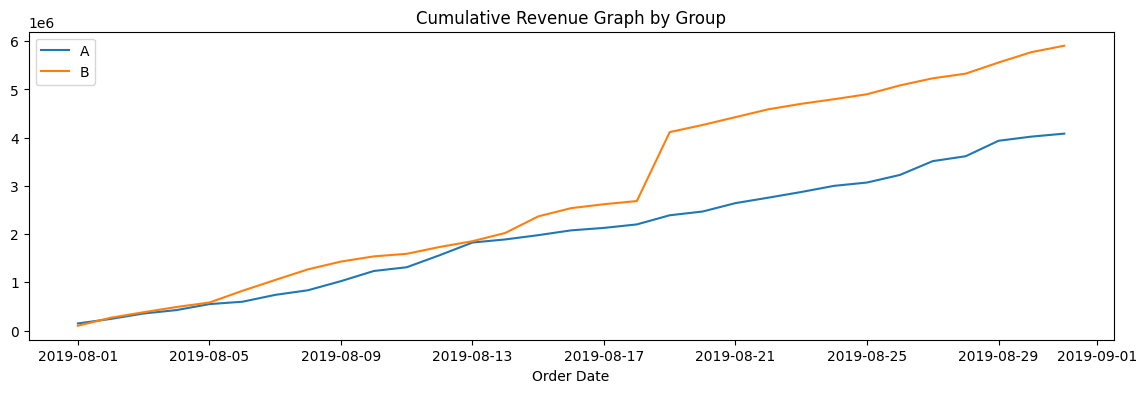

In [28]:
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# data frame with the cumulative number of orders and cumulative revenue by day in group A
cummulativeRevenueA = ordersAggregated[ordersAggregated['group']=='A'][['date','revenue', 'orders']]

# data frame with cumulative number of orders and cumulative revenue by day in group B
cummulativeRevenueB = ordersAggregated[ordersAggregated['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(14,4))
# We are plotting the revenue graph for Group A
plt.plot(cummulativeRevenueA['date'], cummulativeRevenueA['revenue'], label='A')

# We are plotting the revenue graph for Group B
plt.plot(cummulativeRevenueB['date'], cummulativeRevenueB['revenue'], label='B')

plt.legend()
plt.title('Cumulative Revenue Graph by Group')
plt.xlabel("Order Date")

    Revenue increases almost uniformly throughout the test.
    However, the revenue graph for Group B shows sharp increases at several points (from
    2019-08-17 to 2019-08-21). This may indicate spikes in the number of orders or
    the presence of very expensive orders in the sample. Such outliers require further
    analysis.

    According to this graph, Group B's revenue is significantly higher than Group A's.

### 2.2. Cumulative Average Order Value Graph by Group<a class="anchor" id="2-2-bullet"></a>

Text(0.5, 0, 'Order Date')

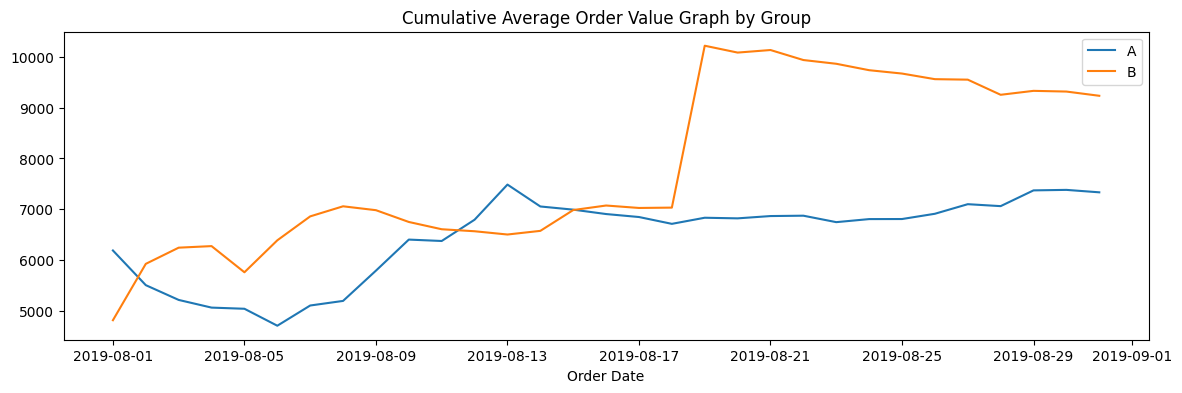

In [29]:
plt.figure(figsize=(14,4))
plt.plot(cummulativeRevenueA['date'], cummulativeRevenueA['revenue']/cummulativeRevenueA['orders'], label='A')
plt.plot(cummulativeRevenueB['date'], cummulativeRevenueB['revenue']/cummulativeRevenueB['orders'], label='B')
plt.legend()
plt.title('Cumulative Average Order Value Graph by Group')
plt.xlabel("Order Date")

    At the beginning of the test, the average order value in Group A was higher than in Group B.

    Then, Group A declined, while Group B increased.

    Both graphs show spikes, a sharp increase in the average order value.
    Perhaps large orders were included in the groups (the sharp spike in the graph).

    The average order value becomes more uniform toward the middle of the test: starting on 2019-08-17, Group B's average order value is significantly higher than Group A's.

### 2.3. Graph of the Relative Change in the Cumulative Average Order Value of Group B Versus Group A<a class="anchor" id="2-3-bullet"></a>

Text(0.5, 0, 'Order Date')

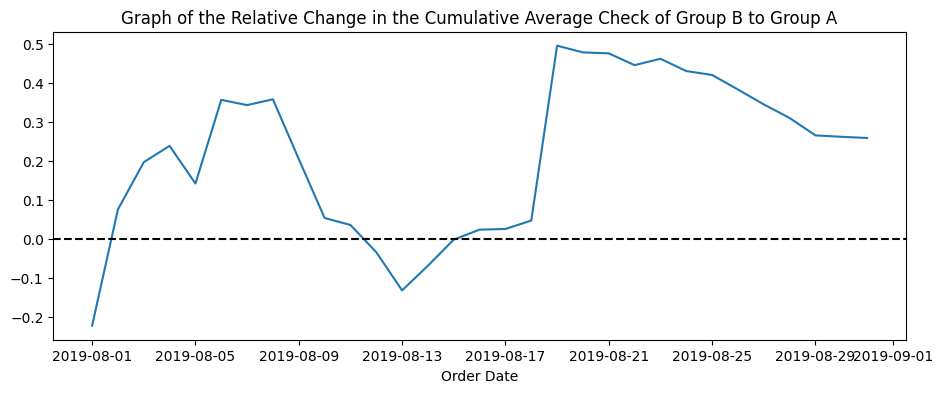

In [30]:
# We collect data in one data frame.
mergedCummulativeRevenue = cummulativeRevenueA.merge(cummulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# We build the ratio of average checks
plt.figure(figsize=(11,4))
plt.plot(mergedCummulativeRevenue['date'], (mergedCummulativeRevenue['revenueB']/mergedCummulativeRevenue['ordersB'])/(mergedCummulativeRevenue['revenueA']/mergedCummulativeRevenue['ordersA'])-1)

# Add the X axis
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Graph of the Relative Change in the Cumulative Average Check of Group B to Group A')
plt.xlabel("Order Date")

    At the beginning of the test, the average order value in Group B was lower than in Group A. Then we see an increase, a decline, and then an increase again. After this, during the second half of the test, the average order value in Group B was significantly higher than that in Group A. At several points in the graph, the differences between the segments jump sharply. This suggests that the data contains large orders and outliers.

### 2.4. Graph of the Cumulative Conversion Rate by Group<a class="anchor" id="2-4-bullet"></a>

In [31]:
# получаем агрегированные кумулятивные по дням данные о посетителях интернет-магазина 
visitorsAggregated = datesGroups.apply(lambda x: df_visitors[np.logical_and(df_visitors['date'] <= x['date'], df_visitors['group'] == x['group'])].agg({'date' : 'max', 'group' : 'max', 'visitors' : 'sum'}), axis=1).sort_values(by=['date','group'])

# объединяем кумулятивные данные в одной таблице и присваиваем ее столбцам понятные названия
cummulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cummulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

In [32]:
cummulativeData.head()

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,24,20,148579,719
1,2019-08-01,B,21,20,101217,713
2,2019-08-02,A,44,38,242401,1338
3,2019-08-02,B,45,43,266748,1294
4,2019-08-03,A,68,62,354874,1845


Text(0.5, 0, 'Date')

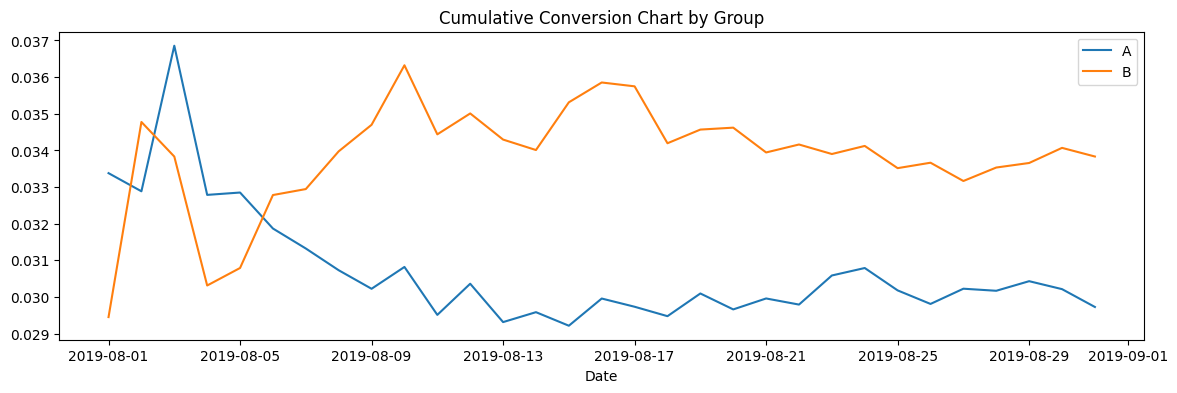

In [33]:
# считаем кумулятивную конверсию
cummulativeData['conversion'] = cummulativeData['orders']/cummulativeData['visitors']

# отделяем данные по группе A
cummulativeDataA = cummulativeData[cummulativeData['group']=='A']

# отделяем данные по группе B
cummulativeDataB = cummulativeData[cummulativeData['group']=='B']

# строим графики
plt.figure(figsize=(14,4))
plt.plot(cummulativeDataA['date'], cummulativeDataA['conversion'], label='A')
plt.plot(cummulativeDataB['date'], cummulativeDataB['conversion'], label='B')
plt.legend()
plt.title('Cumulative Conversion Chart by Group')
plt.xlabel("Date")

    At the beginning of the test, the groups hesitated, but then Group B's conversion rate surged ahead and stabilized, while Group A's conversion rate dipped and also stabilized.

### 2.5. Graph of the Relative Change in the Cumulative Conversion Rate of Group B Versus Group A<a class="anchor" id="2-5-bullet"></a>

Text(0.5, 0, 'Date')

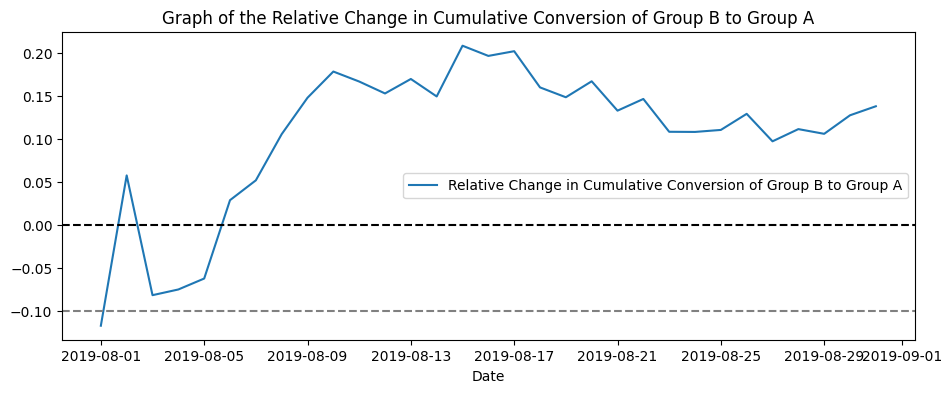

In [34]:
mergedCummulativeConversions = cummulativeDataA[['date','conversion']].merge(cummulativeDataB[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.figure(figsize=(11,4))
plt.plot(mergedCummulativeConversions['date'], mergedCummulativeConversions['conversionB']/mergedCummulativeConversions['conversionA']-1, label="Relative Change in Cumulative Conversion of Group B to Group A")
plt.legend()

plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=-0.1, color='grey', linestyle='--')
plt.title('Graph of the Relative Change in Cumulative Conversion of Group B to Group A')
plt.xlabel("Date")

    At the beginning of the test, Group B was significantly behind Group A, but then pulled ahead.
    Overall, it's safe to say that the conversion rate has stabilized. However, it's worth first
    analyzing any anomalies; they might change the picture.

### 2.6. Graph of the Number of Orders by User<a class="anchor" id="2-6-bullet"></a>

In [35]:
ordersByUsers = df_orders.drop(['group', 'revenue', 'date'], axis=1).groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})

ordersByUsers.columns = ['userId','orders']

print(ordersByUsers.sort_values(by='orders',ascending=False).head(5))

          userId  orders
1023  4256040402      11
591   2458001652      11
569   2378935119       9
487   2038680547       8
44     199603092       5


In [36]:
ordersByUsers['orders'].unique()

array([ 1,  2,  5,  3,  4,  8,  9, 11])

    There are users who placed 5, 8, 9, and 11 orders.
    Significantly more than the average user in a week.
    Let's plot a histogram of the distribution of the number of orders per user.

Text(0.5, 1.0, 'Number of Orders per User')

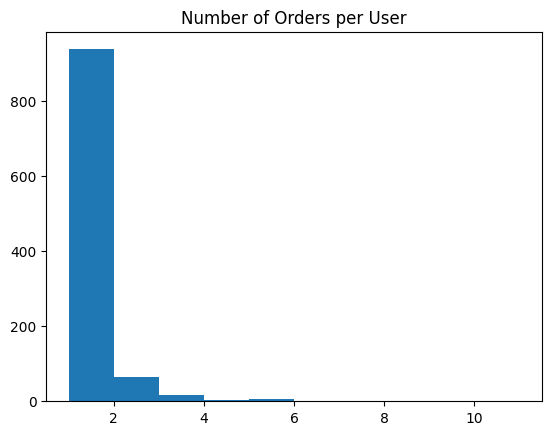

In [37]:
plt.hist(ordersByUsers['orders'])
plt.title('Number of Orders per User')

    Most customers ordered only once. However, the proportion of users with 2-3 orders is also significant.
    Let's plot a scatter plot of the number of orders per user:

Text(0.5, 1.0, 'Number of Orders per User')

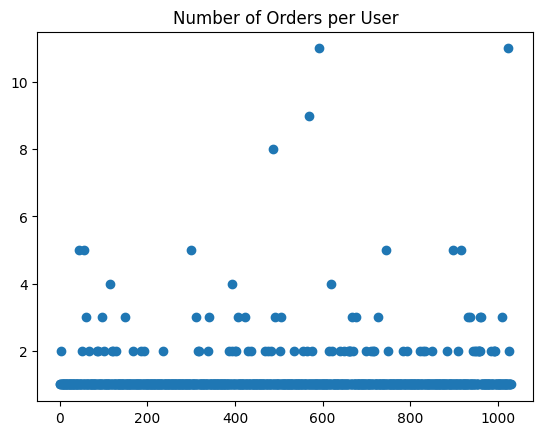

In [38]:
x_values = pd.Series(range(0,len(ordersByUsers)))

plt.scatter(x_values, ordersByUsers['orders'])
plt.title('Number of Orders per User')

The findings are confirmed: many users have 2-3 orders. Their exact share is unclear—it's unclear whether they should be considered anomalies or not.

### 2.7. 95th and 99th Percentiles of the Number of Orders per User. The Cutoff for Identifying Anomalous Users<a class="anchor" id="2-7-bullet"></a>

In [39]:
np.percentile(ordersByUsers['orders'], [90, 95, 97, 98, 99])

array([1., 2., 2., 3., 4.])

    No more than 5% of users placed more than two orders.
    We'll select three orders per user as the lower bound for the number of orders (the 98th percentile),
    and filter out outliers based on that.

### 2.8. Graph of the Order Value<a class="anchor" id="2-8-bullet"></a>

Text(0.5, 1.0, 'Order Value Chart')

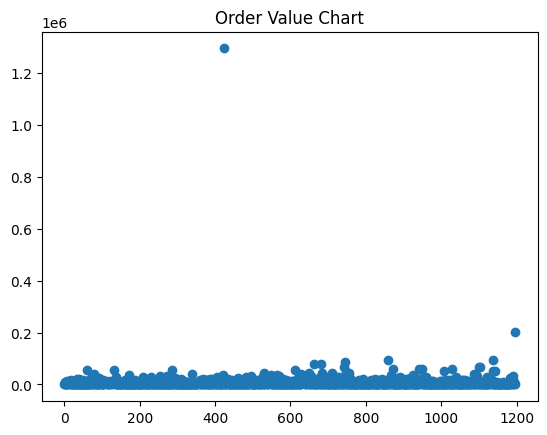

In [40]:
x_values = pd.Series(range(0,len(df_orders['revenue'])))
plt.scatter(x_values, df_orders['revenue'])
plt.title('Order Value Chart')

    The graph shows two outliers—abnormally expensive orders.
    A single order valued over 1,200,000 rubles can significantly distort the data.
    Let's zoom in on the graph to examine the order distribution in more detail.

(0.0, 60000.0)

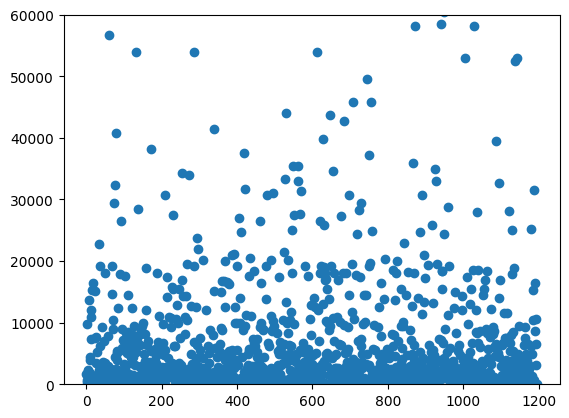

In [41]:
x_values = pd.Series(range(0,len(df_orders['revenue'])))
plt.scatter(x_values, df_orders['revenue'])
plt.ylim(0, 60000)

We see that the number of orders over 30 000 rubles is very small.

### 2.9. 95th and 99th Percentiles of the Order Value. Boundary for Detecting Outlier Orders<a class="anchor" id="2-9-bullet"></a>

In [42]:
np.percentile(df_orders['revenue'], [90, 95, 96, 97, 98, 99])

array([18168. , 28000. , 31382. , 35485. , 44133.2, 58233.2])

    No more than 5% of orders are over 28 000 rubles, and no more than 1% are over 58 233 rubles.
    Let's take 30 000 rubles as the lower bound for order value (the 96th percentile) and filter out outliers using this value.

### 2.10. Statistical Significance of Differences in Conversion Rates Between Groups Based on Raw Data<a class="anchor" id="2-10-bullet"></a>

In [43]:
visitorsADaily = df_visitors[df_visitors['group']=='A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']

visitorsACummulative = visitorsADaily.apply(lambda x: visitorsADaily[visitorsADaily['date'] <= x['date']].agg({'date' : 'max', 'visitorsPerDateA' : 'sum'}), axis=1)
visitorsACummulative.columns = ['date', 'visitorsCummulativeA']

visitorsBDaily = df_visitors[df_visitors['group']=='B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']

visitorsBCummulative = visitorsBDaily.apply(lambda x: visitorsBDaily[visitorsBDaily['date'] <= x['date']].agg({'date' : 'max', 'visitorsPerDateB' : 'sum'}), axis=1)
visitorsBCummulative.columns = ['date', 'visitorsCummulativeB']

In [44]:
ordersADaily = df_orders[df_orders['group']=='A'][['date', 'transactionId', 'visitorId', 'revenue']]\
    .groupby('date', as_index=False)\
    .agg({'visitorId' : pd.Series.nunique, 'revenue' : 'sum'})
ordersADaily.columns = ['date', 'ordersPerDateA', 'revenuePerDateA']

ordersACummulative = ordersADaily.apply(
    lambda x: \
        ordersADaily[ordersADaily['date'] <= x['date']]\
            .agg({
                'date' : 'max',
                'ordersPerDateA' : 'sum',
                'revenuePerDateA' : 'sum'}), axis=1).sort_values(by=['date'])
ordersACummulative.columns = ['date', 'ordersCummulativeA', 'revenueCummulativeA']

ordersBDaily = df_orders[df_orders['group']=='B'][['date', 'transactionId', 'visitorId', 'revenue']]\
    .groupby('date', as_index=False)\
    .agg({'transactionId' : pd.Series.nunique, 'revenue' : 'sum'})
ordersBDaily.columns = ['date', 'ordersPerDateB', 'revenuePerDateB']

ordersBCummulative = ordersBDaily.apply(
    lambda x: \
        ordersBDaily[ordersBDaily['date'] <= x['date']]\
            .agg({
                'date' : 'max',
                'ordersPerDateB' : 'sum',
                'revenuePerDateB' : 'sum'}), axis=1).sort_values(by=['date'])
ordersBCummulative.columns = ['date', 'ordersCummulativeB', 'revenueCummulativeB']

In [45]:
data = ordersADaily.merge(ordersBDaily, left_on='date', right_on='date', how='left')\
    .merge(ordersACummulative, left_on='date', right_on='date', how='left')\
    .merge(ordersBCummulative, left_on='date', right_on='date', how='left')\
    .merge(visitorsADaily, left_on='date', right_on='date', how='left')\
    .merge(visitorsBDaily, left_on='date', right_on='date', how='left')\
    .merge(visitorsACummulative, left_on='date', right_on='date', how='left')\
    .merge(visitorsBCummulative, left_on='date', right_on='date', how='left')


**Let's calculate the statistical significance of the difference in conversion between groups.**

In [46]:
ordersByUsersA = df_orders[df_orders['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersA.columns = ['userId', 'orders']

ordersByUsersB = df_orders[df_orders['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersB.columns = ['userId', 'orders']

In [47]:
sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)

sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)

In [48]:
ordersByUsersA = df_orders[df_orders['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersA.columns = ['userId', 'orders']

ordersByUsersB = df_orders[df_orders['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersB.columns = ['userId', 'orders']

sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)

sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)

In [49]:
print("{0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))

print("{0:.3f}".format(sampleB.mean()/sampleA.mean()-1))

0.017
0.138


**Conclusion:**

According to the raw data, there are differences in the conversion rates between groups A and B.
The first number is p-value = 0.008, which is less than 0.05. This means that the null hypothesis that there are no statistically significant differences in conversion rates between the groups is not confirmed.
According to the raw data, the relative advantage of group B is 13.8%—the second number in the conclusion.

### 2.11. Statistical Significance of Differences in Average Order Value Between Groups Based on Raw Data <a class="anchor" id="2-11-bullet"></a>

    To calculate the statistical significance of differences in average order value between segments,
    we'll pass order revenue data to the mannwhitneyu() criterion.
    We'll also find the relative differences in average order value between groups:

In [50]:
print("{0:.3f}".format(stats.mannwhitneyu(df_orders[df_orders['group']=='A']['revenue'], df_orders[df_orders['group']=='B']['revenue'])[1]))
print("{0:.3f}".format(df_orders[df_orders['group']=='B']['revenue'].mean()/df_orders[df_orders['group']=='A']['revenue'].mean()-1))

0.729
0.259


    The p-value is significantly greater than 0.05. Therefore, there is no reason to reject the null hypothesis and assume that there are differences in the average check. However, the average check for Group B is significantly higher than the average check for Group A (by 25.9%).

### 2.12. Statistical Significance of Differences in Conversion Rates Between Groups Based on Cleaned Data<a class="anchor" id="2-12-bullet"></a>

In the tasks above, the 95th and 99th percentiles of average checks were found, and they are equal to
28 000 and 58 233 rubles. The 95th and 99th percentiles of the number of orders per user are equal to
2 and 4 orders per user.

We'll define anomalous users as those who placed 4 or more orders or placed an order greater than
30 000 rubles.
We'll create a cross-section of users with more than 3 orders (usersWithManyOrders) and users
who placed orders greater than 30 000 (usersWithExpensiveOrders).
We'll combine them in the abnormalUsers table.
We'll find the total number of anomalous users using the shape() method.

In [51]:
usersWithManyOrders = pd.concat([ordersByUsersA[ordersByUsersA['orders'] > 3]['userId'], ordersByUsersB[ordersByUsersB['orders'] > 3]['userId']], axis = 0)
usersWithExpensiveOrders = df_orders[df_orders['revenue'] > 30000]['visitorId']
abnormalUsers = pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis = 0).drop_duplicates().sort_values()
print(abnormalUsers.head(5))
print(abnormalUsers.shape)

1099    148427295
18      199603092
928     204675465
23      237748145
684     358944393
dtype: int64
(57,)


    A total of 57 anomalous users.
    Let's calculate the statistical significance of differences in conversion rates between test groups using the cleaned data.
    First, let's prepare samples of the number of orders by user across test groups:

In [52]:
sampleAFiltered = pd.concat([ordersByUsersA[np.logical_not(ordersByUsersA['userId'].isin(abnormalUsers))]['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])),name='orders')],axis=0)

sampleBFiltered = pd.concat([ordersByUsersB[np.logical_not(ordersByUsersB['userId'].isin(abnormalUsers))]['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])),name='orders')],axis=0)

In [53]:
#Let us apply the Mann-Whitney statistical test to the obtained samples:
print("{0:.3f}".format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print("{0:.3f}".format(sampleBFiltered.mean()/sampleAFiltered.mean()-1))

0.018
0.148


Conversion results remained virtually unchanged.

**Conclusion:**

According to the "cleaned" data, there are differences in the conversion rates of groups A and B.
The first number is p-value = 0.009, which is less than 0.05.
Therefore, the null hypothesis that there are no statistically significant differences in conversion between the groups was not confirmed.
According to the "cleaned" data, the relative advantage of group B is 14.8%.

### 2.13. Statistical Significance of Differences in Average Order Value Between Groups Based on Cleaned Data<a class="anchor" id="2-13-bullet"></a>

In [54]:
print("{0:.3f}".format(stats.mannwhitneyu(
    df_orders[np.logical_and(
        df_orders['group']=='A',
        np.logical_not(df_orders['visitorId'].isin(abnormalUsers)))]['revenue'],
    df_orders[np.logical_and(
        df_orders['group']=='B',
        np.logical_not(df_orders['visitorId'].isin(abnormalUsers)))]['revenue'])[1]))

0.958


In [55]:
print("{0:.3f}".format(
    df_orders[np.logical_and(df_orders['group']=='B',np.logical_not(df_orders['visitorId'].isin(abnormalUsers)))]['revenue'].mean()/
    df_orders[np.logical_and(df_orders['group']=='A',np.logical_not(df_orders['visitorId'].isin(abnormalUsers)))]['revenue'].mean() - 1))

-0.020


The first number is a p-value of 0.479 greater than 0.05.
Therefore, there is no reason to reject the null hypothesis and assume that there are differences in the average check.
The average check for Group B was 2% lower than the average check for Group A. According to the unadjusted data, the average
check for Group B was significantly higher than the average check for Group A (by 25.9%).

### Step 3. Decision Based on A/B Test Results <a class="anchor" id="3-bullet"></a>

- there are statistically significant differences in conversion between groups A and B (both raw and cleaned data);

- there are no statistically significant differences in average order value between groups A and B (both raw and cleaned data).

This test can be stopped and considered successful. User-to-customer conversion for group B is statistically significantly higher than for group A. However, the average order value between the groups does not differ.
